# Trabalho Deep Learning - 2026

## Dependencies

In [101]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pathlib

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split

# Auxiliary functions /code

In [102]:
def count_n_images_iterator(this_iterator, name, what='images'):
    """
    Function to count the number of items (images/batches) in the dataset that
    is an iterator. Does not return. Prints a string.

    Input:
        this_iterator: tf.data.Dataset
            Iterator containing the data. TensorFlow Dataset.
        name: str
            Name of the dataset. Should be 'train','test','validation'
        what: str
            Specifies if we are dealing with single images or batches. Should
            be 'images' or 'batches'.

    Output:
        None
    """

    count_items = 0
    for item, label in this_iterator:
        count_items += 1

    print(f'The {name} dataset has {count_items} {what}.')

In [103]:
def plot_acuracy_loss(history):
    """
    Adapted from: https://www.tensorflow.org/tutorials/images/classification
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(epochs)

    plt.figure(figsize=(8, 8))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

# 1. Problem Definition and Data Collection

## What problem are we solving?

**Multi-class medical image classification** — a supervised learning problem.

The goal is to train a Convolutional Neural Network (CNN) that, given a chest X-ray image, automatically identifies the patient's condition among 4 possible classes:

| Class | Description |
|---|---|
| **Normal** | Healthy lungs with no abnormalities. Clear lung fields, no opacities or infiltrates visible. |
| **Lung Opacity** | A non-specific radiological finding where areas of the lung appear denser than normal. Caused by a range of conditions such as bacterial pneumonia, pulmonary oedema, or heart failure — but not COVID-19 or viral pneumonia. |
| **COVID-19** | Lung infection caused by the SARS-CoV-2 virus. Typically shows bilateral ground-glass opacities, often in the periphery of the lungs. Visually similar to Lung Opacity, making classification challenging. |
| **Viral Pneumonia** | Lung infection caused by other viruses (e.g. influenza, RSV). Shows diffuse infiltrates, often with a different distribution pattern than COVID-19. |

> **Note:** Lung Opacity and COVID-19 are the hardest pair to distinguish — both cause opacities on X-rays. We expect the model to confuse these two classes more than any other pair.

## What type of data?

- **Type:** Chest X-ray images
- **Format:** PNG, 299×299 pixels, grayscale (1 channel)
- **Source:** [COVID-19 Radiography Database (Kaggle)](https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database/data)
- **Classes and distribution:**

| Class | No. of Images |
|---|---|
| Normal | 10,192 |
| Lung Opacity (non-COVID) | 6,012 |
| COVID-19 | 3,616 |
| Viral Pneumonia | 1,345 |
| **Total** | **21,165** |

> **Important note:** The dataset is **imbalanced** — Normal has ~7.5× more images than Viral Pneumonia. This will affect training and may require class weights or oversampling strategies.

## What will the model output?

The model produces a **vector of 4 probabilities** (one per class) using `softmax` in the final layer. The class with the highest probability is the final prediction.

```
Input:  chest X-ray image (299×299, grayscale)
Output: [P(Normal), P(Lung Opacity), P(COVID-19), P(Viral Pneumonia)]
```

## Evaluation metric

**Accuracy** as the primary metric, but given the class imbalance, the **confusion matrix** and per-class metrics (precision, recall, F1-score) are also important — particularly for COVID-19, where false negatives carry high clinical cost.

# Dataset Size Comparison

Total Training Pixels = Number_of_Images × Height × Width × Channels

| Dataset      | Train Images | Image Size | Channels | Pixels per Image | Total Training Pixels |
|--------------|-------------|------------|----------|------------------|-----------------------|
| MNIST        | 60,000      | 28×28      | 1        | 784              | ~47M                  |
| CIFAR-10     | 50,000      | 32×32      | 3        | 3,072            | ~154M                 |
| CIFAR-100    | 50,000      | 32×32      | 3        | 3,072            | ~154M                 |
| COVID-19     | 21,165      | 299×299    | 1        | 89,401           | ~1.9B                 |
| ImageNet     | ~1,280,000  | 224×224    | 3        | 150,528          | ~193B                 |

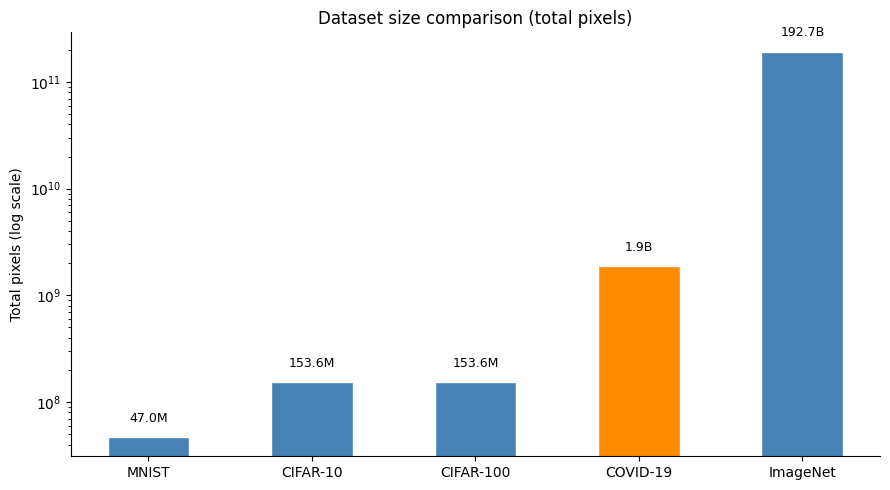

In [104]:
datasets     = ['MNIST', 'CIFAR-10', 'CIFAR-100', 'COVID-19', 'ImageNet']
total_pixels = [
    60_000    * 28  * 28  * 1,   # MNIST
    50_000    * 32  * 32  * 3,   # CIFAR-10
    50_000    * 32  * 32  * 3,   # CIFAR-100
    21_165    * 299 * 299 * 1,   # COVID-19 (ours)
    1_280_000 * 224 * 224 * 3,   # ImageNet
]

colors = ['steelblue', 'steelblue', 'steelblue', 'darkorange', 'steelblue']

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(datasets, total_pixels, color=colors, edgecolor='white', width=0.5)

ax.set_yscale('log')
ax.set_ylabel('Total pixels (log scale)')
ax.set_title('Dataset size comparison (total pixels)')

ax.grid(False)
ax.yaxis.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, total_pixels):
    label = f'{val/1e9:.1f}B' if val >= 1e9 else f'{val/1e6:.1f}M'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
            label, ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 2. Load Data

We start by scanning the folder structure to collect all image file paths and their corresponding class labels. Each class folder maps to an integer label (0–3). We also inspect the class distribution to confirm the dataset is imbalanced — this will be relevant when training the model.

In [105]:
DATA_DIR = pathlib.Path('.')
IMG_SIZE = 299
BATCH_SIZE = 32
SEED = 42

CLASS_NAMES = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

# Collect all image paths and corresponding integer labels
all_paths, all_labels = [], []

for label, class_name in enumerate(CLASS_NAMES):
    images = sorted((DATA_DIR / class_name / 'images').glob('*.png'))
    all_paths.extend([str(p) for p in images])
    all_labels.extend([label] * len(images))

total = len(all_paths)
print(f'Total images: {total}\n')
print(f'{"Class":<25} {"Count":>6}  {"Share":>6}')
print('-' * 40)
for i, name in enumerate(CLASS_NAMES):
    count = all_labels.count(i)
    print(f'{name:<25} {count:>6}  {count/total*100:>5.1f}%')
print('-' * 40)
print(f'{"TOTAL":<25} {total:>6}  100.0%')

Total images: 21165

Class                      Count   Share
----------------------------------------
COVID                       3616   17.1%
Lung_Opacity                6012   28.4%
Normal                     10192   48.2%
Viral Pneumonia             1345    6.4%
----------------------------------------
TOTAL                      21165  100.0%


## 2.1 Sample Image Inspection

Before building the dataset pipeline, we inspect a sample image to confirm its properties — dimensions, number of channels, data type, and pixel value range. This ensures our loading and preprocessing steps are correctly configured.

Sample class  : COVID
File path     : COVID\images\COVID-1.png
Shape         : (299, 299, 1)         (height x width x channels)
Data type     : <dtype: 'uint8'>
Pixel range   : [0 , 255]
Total pixels  : 89,401


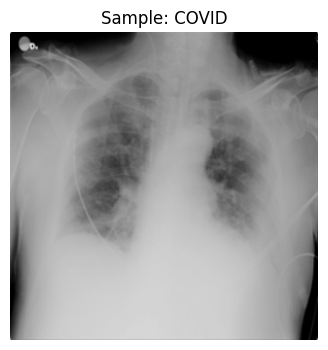

In [106]:
# Load a single sample image to inspect its properties
sample_path = all_paths[0]
sample_class = CLASS_NAMES[all_labels[0]]

raw = tf.io.read_file(sample_path)
image = tf.image.decode_png(raw, channels=1)   # decode as grayscale

print(f'Sample class  : {sample_class}')
print(f'File path     : {sample_path}')
print(f'Shape         : {image.shape}         (height x width x channels)')
print(f'Data type     : {image.dtype}')
print(f'Pixel range   : [{int(tf.reduce_min(image))} , {int(tf.reduce_max(image))}]')
print(f'Total pixels  : {image.shape[0] * image.shape[1] * image.shape[2]:,}')

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(image.numpy().squeeze(), cmap='gray')
plt.title(f'Sample: {sample_class}')
plt.axis('off')
plt.show()

In [107]:
# Verify image shapes across the entire dataset
from PIL import Image

shape_counts = {}
for path in all_paths:
    with Image.open(path) as img:
        shape = (img.height, img.width, len(img.getbands()))
        shape_counts[shape] = shape_counts.get(shape, 0) + 1

print(f'{"Shape":<25} {"Count":>6}  {"Share":>6}')
print('-' * 40)
for shape, count in sorted(shape_counts.items()):
    print(f'{str(shape):<25} {count:>6}  {count/len(all_paths)*100:>5.1f}%')

if len(shape_counts) > 1:
    print('\nNote: all images will be decoded as grayscale (channels=1) in the pipeline.')
    print('tf.image.decode_png(..., channels=1) handles this automatically.')

Shape                      Count   Share
----------------------------------------
(299, 299, 1)              21025   99.3%
(299, 299, 3)                140    0.7%

Note: all images will be decoded as grayscale (channels=1) in the pipeline.
tf.image.decode_png(..., channels=1) handles this automatically.


## 2.2 Shape Verification

We verify that all images in the dataset share the same dimensions. A single sample cannot guarantee uniformity — we need to check all 21,165 files.

In [108]:
# Find which class the RGB (3-channel) images belong to
from PIL import Image

rgb_per_class = {name: [] for name in CLASS_NAMES}

for path, label in zip(all_paths, all_labels):
    with Image.open(path) as img:
        if len(img.getbands()) == 3:
            rgb_per_class[CLASS_NAMES[label]].append(path)

print(f'{"Class":<25} {"RGB images":>10}')
print('-' * 37)
for name, paths in rgb_per_class.items():
    print(f'{name:<25} {len(paths):>10}')
    for p in paths[:5]:
        print(f'    {p}')

Class                     RGB images
-------------------------------------
COVID                              0
Lung_Opacity                       0
Normal                             0
Viral Pneumonia                  140
    Viral Pneumonia\images\Viral Pneumonia-1004.png
    Viral Pneumonia\images\Viral Pneumonia-1005.png
    Viral Pneumonia\images\Viral Pneumonia-1017.png
    Viral Pneumonia\images\Viral Pneumonia-1084.png
    Viral Pneumonia\images\Viral Pneumonia-1123.png


## 2.3 Investigating RGB Outliers

The shape check revealed that 140 images (0.7%) have 3 channels instead of 1. We investigate which class they belong to and whether they contain actual colour information or are simply grayscale images stored in RGB format.

File        : Viral Pneumonia\images\Viral Pneumonia-1004.png
Mode        : RGB
Shape       : (299, 299, 3)
R channel   : min=0, max=191, mean=119.7
G channel   : min=0, max=191, mean=119.7
B channel   : min=0, max=191, mean=119.7

R==G: True, R==B: True  →  channels are identical (fake RGB)


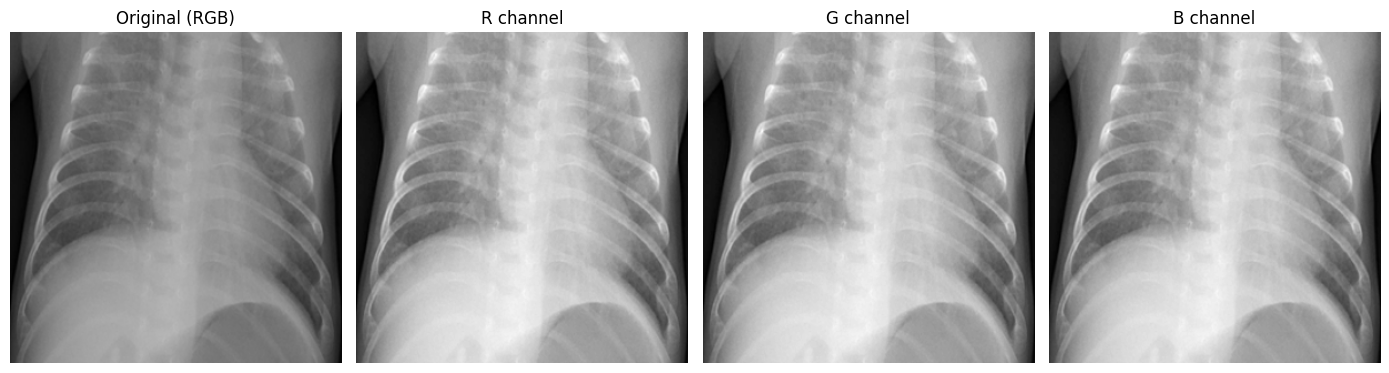

In [109]:
# Inspect one RGB image from Viral Pneumonia
from PIL import Image
import numpy as np

rgb_path = rgb_per_class['Viral Pneumonia'][0]
with Image.open(rgb_path) as img:
    arr = np.array(img)

print(f'File        : {rgb_path}')
print(f'Mode        : {img.mode}')
print(f'Shape       : {arr.shape}')
print(f'R channel   : min={arr[:,:,0].min()}, max={arr[:,:,0].max()}, mean={arr[:,:,0].mean():.1f}')
print(f'G channel   : min={arr[:,:,1].min()}, max={arr[:,:,1].max()}, mean={arr[:,:,1].mean():.1f}')
print(f'B channel   : min={arr[:,:,2].min()}, max={arr[:,:,2].max()}, mean={arr[:,:,2].mean():.1f}')

r_eq_g = np.array_equal(arr[:,:,0], arr[:,:,1])
r_eq_b = np.array_equal(arr[:,:,0], arr[:,:,2])
print(f'\nR==G: {r_eq_g}, R==B: {r_eq_b}  →  {"channels are identical (fake RGB)" if r_eq_g and r_eq_b else "channels differ (true RGB)"}')

# Display all 3 channels side by side
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(arr)
axes[0].set_title('Original (RGB)')
for i, ch in enumerate(['R', 'G', 'B']):
    axes[i+1].imshow(arr[:,:,i], cmap='gray')
    axes[i+1].set_title(f'{ch} channel')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

The 140 RGB images are **fake RGB** — all three channels are identical, meaning they are grayscale X-rays stored in an RGB container. This is likely an artefact of how those images were originally exported. Since there is no actual colour information, our pipeline handles them correctly: `tf.image.decode_png(..., channels=1)` converts all images to single-channel grayscale on load, regardless of the source format.

## 2.4 Visual Exploration

To build intuition about the problem, we display a sample of images from each class. This highlights how visually similar the X-rays can be across conditions — which explains why automated classification is both useful and challenging.

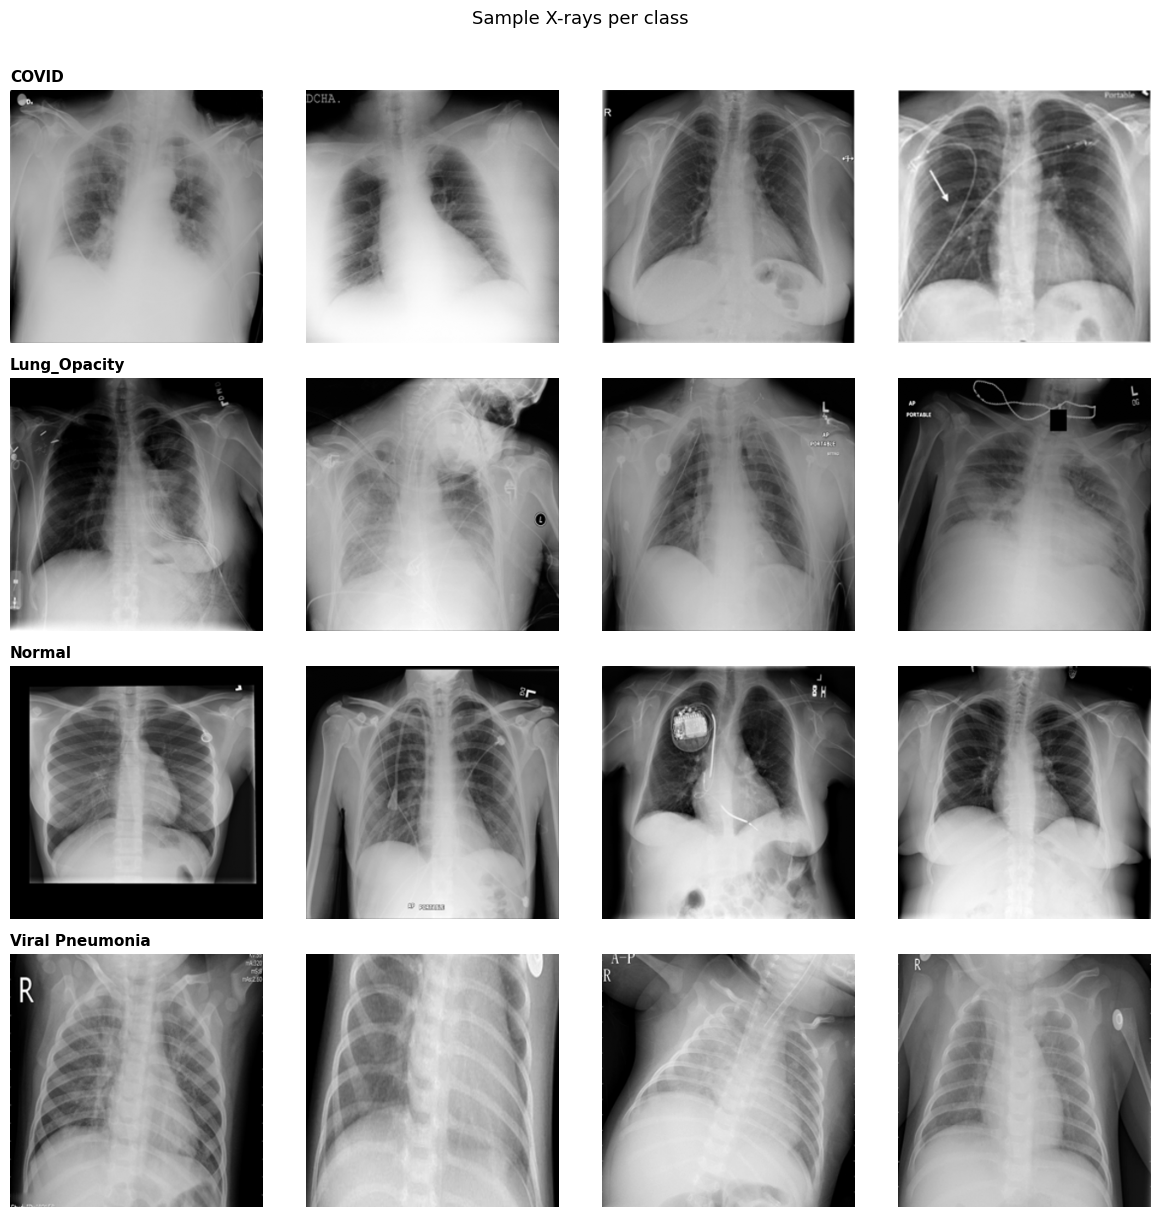

In [110]:
SAMPLES_PER_CLASS = 4

fig, axes = plt.subplots(len(CLASS_NAMES), SAMPLES_PER_CLASS, figsize=(SAMPLES_PER_CLASS * 3, len(CLASS_NAMES) * 3))

for row, (label, class_name) in enumerate(enumerate(CLASS_NAMES)):
    # Get paths for this class and pick evenly spaced samples
    class_paths = [p for p, l in zip(all_paths, all_labels) if l == label]
    indices = np.linspace(0, len(class_paths) - 1, SAMPLES_PER_CLASS, dtype=int)
    samples = [class_paths[i] for i in indices]

    for col, path in enumerate(samples):
        raw = tf.io.read_file(path)
        img = tf.image.decode_png(raw, channels=1).numpy().squeeze()

        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(class_name, fontsize=11, fontweight='bold', loc='left')

plt.suptitle('Sample X-rays per class', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Visual inspection of the dataset reveals significant variability across images — including different crop levels, brightness, contrast, and the presence of medical annotations and devices. This variability is realistic, as it reflects real clinical data collected from multiple sources and acquisition settings. However, it adds complexity to the classification task: the model must learn to focus on clinically relevant lung features rather than these artefacts.

This motivates the use of **data augmentation** during training (e.g. random brightness and contrast adjustments), which can help the model become more robust to this kind of variability.

## 2.5 Dataset Splitting

Now that we are sure all images are the same size, we split the dataset into **train (70%) / validation (15%) / test (15%)** using a **stratified** split. Stratification ensures that the class imbalance is preserved proportionally across all three subsets.

Without it, a random split could under-represent a minority class (e.g. Viral Pneumonia) in one of the splits:
- In the **training set**, the model would see fewer examples of that class, learning its patterns poorly. It may become biased towards predicting the majority class, since that minimizes loss more easily. If Viral Pneumonia drops from 6% to 2%, the model may almost never predict it.
- In the **validation set**, hyperparameter tuning decisions are made on misleading performance estimates. A model that never predicts Viral Pneumonia might still look decent on accuracy if that class is rare in validation.
- In the **test set**, the final reported performance becomes unreliable — we can no longer trust that the numbers represent real-world behaviour.
- More importantly, in the **real world**, missing a COVID-19 or Viral Pneumonia diagnosis (false negative) is dangerous, as a sick patient could be sent home without treatment.

In short, stratification is not a nice-to-have in medical datasets — it directly affects whether our evaluation is trustworthy.

In [111]:
# Stratified split: preserves class distribution in each subset
# Without stratify=, a random split could over/under-represent minority classes
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=SEED
)
# Result: 70% train / 15% val / 15% test

print(f'{"Split":<8} {"Total":>6}  {"COVID":>6}  {"Lung_Op":>8}  {"Normal":>7}  {"Viral":>6}')
print('-' * 50)
for split_name, labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    n = len(labels)
    counts = [labels.count(i) for i in range(4)]
    print(f'{split_name:<8} {n:>6}  ' + '  '.join(f'{c:>6} ({c/n*100:.0f}%)' for c in counts))

Split     Total   COVID   Lung_Op   Normal   Viral
--------------------------------------------------
Train     14815    2531 (17%)    4208 (28%)    7134 (48%)     942 (6%)
Val        3175     543 (17%)     902 (28%)    1529 (48%)     201 (6%)
Test       3175     542 (17%)     902 (28%)    1529 (48%)     202 (6%)


## 2.6 Building the Data Pipeline

Finally, we build `tf.data.Dataset` pipelines for each split. Each image is loaded from disk, decoded as grayscale, and normalized to [0, 1]. Images are grouped into batches of 32 and prefetched so the next batch is prepared in the background while the model trains on the current one.

In [112]:
# Load image from file path, normalize to [0, 1] and keep original size (299x299)
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)     # grayscale → shape (299, 299, 1)
    image = tf.cast(image, tf.float32) / 255.0         # normalize pixel values
    return image, label

def make_dataset(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)  # load next batch while GPU processes current
    return ds

ds_train = make_dataset(train_paths, train_labels)
ds_val   = make_dataset(val_paths,   val_labels)
ds_test  = make_dataset(test_paths,  test_labels)

print('Datasets ready.')
print(f'Batch shape (images): {next(iter(ds_train))[0].shape}')  # (32, 299, 299, 1)

Datasets ready.
Batch shape (images): (32, 299, 299, 1)
